In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, r2_score



 # Dataframe


In [4]:
df = pd.read_csv('deutsche_bank_financial_performance.csv', encoding='latin-1', delimiter=',')
df


,Date,Operating_Income,Expenses,Assets,Liabilities,Equity,Revenue,Cash_Flow,Net_Income,Debt_to_Equity,ROA,Profit_Margin,Interest_Expense,Tax_Expense,Dividend_Payout
0,1/1/2015,4370861.07,3682573.85,1.363403e+08,1.494296e+08,59803407.08,9435946.42,1428845.20,688287.22,2.50,0.01,0.07,609472.14,1042103.16,1170151.42
1,1/2/2015,9556428.76,1186425.69,1.955172e+08,4.725052e+07,55281922.53,12470620.28,1029017.28,8370003.06,0.85,0.04,0.67,699770.11,1329539.73,492998.93
2,1/3/2015,7587945.48,3093297.62,1.519954e+08,1.756590e+08,27447676.11,11882092.09,7320721.28,4494647.86,6.40,0.03,0.38,337977.34,345091.11,1603358.92
3,1/4/2015,6387926.36,3230217.71,2.097483e+08,1.382626e+08,87293509.41,4000698.76,1925965.75,3157708.65,1.58,0.02,0.79,1345468.95,1316373.62,426566.77
4,1/5/2015,2404167.76,2408588.02,8.124073e+07,2.773058e+08,70924670.47,3940243.11,6659376.16,-4420.26,3.91,0.00,0.00,175614.54,136655.30,2808563.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,3/6/2017,8849115.18,3102741.13,2.056449e+08,2.121410e+08,49789633.12,6165216.72,4084005.16,5746374.05,4.26,0.03,0.93,627993.14,835552.46,892162.90
796,3/7/2017,9389064.54,1733723.00,1.195069e+08,3.776259e+08,40096106.11,4135728.96,3164629.81,7655341.54,9.42,0.06,1.85,1046559.67,240065.80,707605.75
797,3/8/2017,6086198.65,857387.16,6.145149e+07,3.530014e+08,45511508.38,12181098.60,5618837.98,5228811.49,7.76,0.09,0.43,726107.79,1160927.80,1420453.37
798,3/9/2017,7269857.41,885462.12,3.406201e+08,5.897583e+07,57694652.82,3592472.21,5466741.19,6384395.29,1.02,0.02,1.78,937145.92,1402043.77,2734468.89


In [5]:

print(df['Date'].head(10))

0     1/1/2015
1     1/2/2015
2     1/3/2015
3     1/4/2015
4     1/5/2015
5     1/6/2015
6     1/7/2015
7     1/8/2015
8     1/9/2015
9    1/10/2015
Name: Date, dtype: object


# Convert Date dtype into datetime


In [6]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.sort_values(by='Date')
df.head()




,Date,Operating_Income,Expenses,Assets,Liabilities,Equity,Revenue,Cash_Flow,Net_Income,Debt_to_Equity,ROA,Profit_Margin,Interest_Expense,Tax_Expense,Dividend_Payout
0,2015-01-01,4370861.07,3682573.85,1.363403e+08,1.494296e+08,59803407.08,9435946.42,1428845.20,688287.22,2.50,0.01,0.07,609472.14,1042103.16,1170151.42
1,2015-01-02,9556428.76,1186425.69,1.955172e+08,4.725052e+07,55281922.53,12470620.28,1029017.28,8370003.06,0.85,0.04,0.67,699770.11,1329539.73,492998.93
2,2015-01-03,7587945.48,3093297.62,1.519954e+08,1.756590e+08,27447676.11,11882092.09,7320721.28,4494647.86,6.40,0.03,0.38,337977.34,345091.11,1603358.92
3,2015-01-04,6387926.36,3230217.71,2.097483e+08,1.382626e+08,87293509.41,4000698.76,1925965.75,3157708.65,1.58,0.02,0.79,1345468.95,1316373.62,426566.77
4,2015-01-05,2404167.76,2408588.02,8.124073e+07,2.773058e+08,70924670.47,3940243.11,6659376.16,-4420.26,3.91,0.00,0.00,175614.54,136655.30,2808563.51


# Resample daily to monthly 

In [7]:
df_Monthly = df.set_index('Date').resample('M').sum()

C:\Users\Shivam\AppData\Local\Temp\ipykernel_4540\4193235811.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_Monthly = df.set_index('Date').resample('M').sum()


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.notnull().sum()

Date                800
Operating_Income    800
Expenses            800
Assets              800
Liabilities         800
Equity              800
Revenue             800
Cash_Flow           800
Net_Income          800
Debt_to_Equity      800
ROA                 800
Profit_Margin       800
Interest_Expense    800
Tax_Expense         800
Dividend_Payout     800
dtype: int64

In [10]:
df.isna().sum()

Date                0
Operating_Income    0
Expenses            0
Assets              0
Liabilities         0
Equity              0
Revenue             0
Cash_Flow           0
Net_Income          0
Debt_to_Equity      0
ROA                 0
Profit_Margin       0
Interest_Expense    0
Tax_Expense         0
Dividend_Payout     0
dtype: int64

In [11]:
df['Date'].isna().sum()


np.int64(0)

In [12]:
numerical_cols=['Operating_Income','Expenses','Assets','Liabilities','Equity','Revenue','Cash_Flow','Net_Income','Debt_to_Equity','ROA','Profit_Margin','Interest_Expense','Tax_Expense','Dividend_Payout']
df[numerical_cols]=df[numerical_cols].apply(pd.to_numeric, errors='coerce')
df.head()

,Date,Operating_Income,Expenses,Assets,Liabilities,Equity,Revenue,Cash_Flow,Net_Income,Debt_to_Equity,ROA,Profit_Margin,Interest_Expense,Tax_Expense,Dividend_Payout
0,2015-01-01,4370861.07,3682573.85,1.363403e+08,1.494296e+08,59803407.08,9435946.42,1428845.20,688287.22,2.50,0.01,0.07,609472.14,1042103.16,1170151.42
1,2015-01-02,9556428.76,1186425.69,1.955172e+08,4.725052e+07,55281922.53,12470620.28,1029017.28,8370003.06,0.85,0.04,0.67,699770.11,1329539.73,492998.93
2,2015-01-03,7587945.48,3093297.62,1.519954e+08,1.756590e+08,27447676.11,11882092.09,7320721.28,4494647.86,6.40,0.03,0.38,337977.34,345091.11,1603358.92
3,2015-01-04,6387926.36,3230217.71,2.097483e+08,1.382626e+08,87293509.41,4000698.76,1925965.75,3157708.65,1.58,0.02,0.79,1345468.95,1316373.62,426566.77
4,2015-01-05,2404167.76,2408588.02,8.124073e+07,2.773058e+08,70924670.47,3940243.11,6659376.16,-4420.26,3.91,0.00,0.00,175614.54,136655.30,2808563.51


In [13]:
df[numerical_cols].isna().sum()


Operating_Income    0
Expenses            0
Assets              0
Liabilities         0
Equity              0
Revenue             0
Cash_Flow           0
Net_Income          0
Debt_to_Equity      0
ROA                 0
Profit_Margin       0
Interest_Expense    0
Tax_Expense         0
Dividend_Payout     0
dtype: int64

In [14]:
for col in numerical_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '', regex=False)   # remove commas
        .str.replace('%', '', regex=False)   # remove percentage signs
        .str.replace('+', '', regex=False)   # remove literal plus signs
        .str.replace('(', '-', regex=False)  # replace "(" with "-"
        .str.replace(')', '', regex=False)   # remove ")"
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.head()


,Date,Operating_Income,Expenses,Assets,Liabilities,Equity,Revenue,Cash_Flow,Net_Income,Debt_to_Equity,ROA,Profit_Margin,Interest_Expense,Tax_Expense,Dividend_Payout
0,2015-01-01,4370861.07,3682573.85,1.363403e+08,1.494296e+08,59803407.08,9435946.42,1428845.20,688287.22,2.50,0.01,0.07,609472.14,1042103.16,1170151.42
1,2015-01-02,9556428.76,1186425.69,1.955172e+08,4.725052e+07,55281922.53,12470620.28,1029017.28,8370003.06,0.85,0.04,0.67,699770.11,1329539.73,492998.93
2,2015-01-03,7587945.48,3093297.62,1.519954e+08,1.756590e+08,27447676.11,11882092.09,7320721.28,4494647.86,6.40,0.03,0.38,337977.34,345091.11,1603358.92
3,2015-01-04,6387926.36,3230217.71,2.097483e+08,1.382626e+08,87293509.41,4000698.76,1925965.75,3157708.65,1.58,0.02,0.79,1345468.95,1316373.62,426566.77
4,2015-01-05,2404167.76,2408588.02,8.124073e+07,2.773058e+08,70924670.47,3940243.11,6659376.16,-4420.26,3.91,0.00,0.00,175614.54,136655.30,2808563.51


# Create a lag feature for 1 months and rolling window for 6 and 12 months revenue


In [16]:
# Convert Revenue to numeric before rolling calculations
df_Monthly['Revenue'] = pd.to_numeric(df_Monthly['Revenue'], errors='coerce')

df_Monthly['Revenue_lag_1m'] = df_Monthly['Revenue'].shift(1)
df_Monthly['Revenue_rolling_6m'] = df_Monthly['Revenue'].rolling(window=6).mean()
df_Monthly['Revenue_rolling_12m'] = df_Monthly['Revenue'].rolling(window=12).mean()
df_Monthly.head(15)



,Operating_Income,Expenses,Assets,Liabilities,Equity,Revenue,Cash_Flow,Net_Income,Debt_to_Equity,ROA,Profit_Margin,Interest_Expense,Tax_Expense,Dividend_Payout,Revenue_lag_1m,Revenue_rolling_6m,Revenue_rolling_12m
Date,,,,,,,,,,,,,,,,,
2015-01-31,1.548892e+08,89163253.94,8.125745e+09,5.772409e+09,1.500881e+09,2.532706e+08,1.308863e+08,6.572591e+07,172.05,0.29,8.01,32111151.55,25032780.47,47250985.81,NaN,NaN,NaN
2015-02-28,1.536333e+08,68585810.15,7.924954e+09,5.720204e+09,1.395960e+09,2.649418e+08,1.146445e+08,8.504747e+07,143.41,0.46,11.89,26225770.59,21692375.36,44159505.50,2.532706e+08,NaN,NaN
2015-03-31,1.641110e+08,69978043.20,1.002646e+10,7.388244e+09,1.759301e+09,2.631500e+08,1.231581e+08,9.413295e+07,200.22,0.32,12.68,32992299.80,25597469.00,42533062.10,2.649418e+08,NaN,NaN
2015-04-30,1.626455e+08,78470383.15,7.216134e+09,7.174264e+09,1.560986e+09,2.320212e+08,1.099035e+08,8.417507e+07,201.33,0.50,17.05,30196461.15,23018399.37,43936039.19,2.631500e+08,NaN,NaN
2015-05-31,1.622931e+08,84757367.47,7.685887e+09,6.434978e+09,1.804726e+09,2.645514e+08,1.582087e+08,7.753577e+07,115.98,0.47,13.48,34357941.33,22841587.90,45952421.29,2.320212e+08,NaN,NaN
2015-06-30,1.513240e+08,73346691.82,8.316817e+09,6.128868e+09,1.666418e+09,2.415060e+08,1.234536e+08,7.797733e+07,138.75,0.35,11.53,33270707.46,21717208.67,46004644.76,2.645514e+08,2.532402e+08,NaN
2015-07-31,1.754762e+08,91601631.24,8.066345e+09,5.849881e+09,1.722216e+09,2.472755e+08,1.412837e+08,8.387461e+07,152.75,0.56,11.97,33803877.34,24349361.60,45059534.67,2.415060e+08,2.522410e+08,NaN
2015-08-31,1.813332e+08,88971173.73,8.589577e+09,6.954321e+09,1.827688e+09,2.683279e+08,1.361086e+08,9.236205e+07,164.32,0.47,13.51,32592339.27,23295656.40,36239628.62,2.472755e+08,2.528053e+08,NaN
2015-09-30,1.903752e+08,86140312.61,9.192913e+09,6.250753e+09,1.803698e+09,2.570457e+08,1.255061e+08,1.042349e+08,143.99,0.51,15.09,28978250.85,22585263.14,48042705.19,2.683279e+08,2.517879e+08,NaN


#  Revenue Growth Rate (Year-over-Year)

In [17]:
df_Monthly['Revenue_YoY_Growth'] = (
    (df_Monthly['Revenue'] - df_Monthly['Revenue'].shift(12)) /
    df_Monthly['Revenue'].shift(12)
) * 100
df_Monthly.head(15)


,Operating_Income,Expenses,Assets,Liabilities,Equity,Revenue,Cash_Flow,Net_Income,Debt_to_Equity,ROA,Profit_Margin,Interest_Expense,Tax_Expense,Dividend_Payout,Revenue_lag_1m,Revenue_rolling_6m,Revenue_rolling_12m,Revenue_YoY_Growth
Date,,,,,,,,,,,,,,,,,,
2015-01-31,1.548892e+08,89163253.94,8.125745e+09,5.772409e+09,1.500881e+09,2.532706e+08,1.308863e+08,6.572591e+07,172.05,0.29,8.01,32111151.55,25032780.47,47250985.81,NaN,NaN,NaN,NaN
2015-02-28,1.536333e+08,68585810.15,7.924954e+09,5.720204e+09,1.395960e+09,2.649418e+08,1.146445e+08,8.504747e+07,143.41,0.46,11.89,26225770.59,21692375.36,44159505.50,2.532706e+08,NaN,NaN,NaN
2015-03-31,1.641110e+08,69978043.20,1.002646e+10,7.388244e+09,1.759301e+09,2.631500e+08,1.231581e+08,9.413295e+07,200.22,0.32,12.68,32992299.80,25597469.00,42533062.10,2.649418e+08,NaN,NaN,NaN
2015-04-30,1.626455e+08,78470383.15,7.216134e+09,7.174264e+09,1.560986e+09,2.320212e+08,1.099035e+08,8.417507e+07,201.33,0.50,17.05,30196461.15,23018399.37,43936039.19,2.631500e+08,NaN,NaN,NaN
2015-05-31,1.622931e+08,84757367.47,7.685887e+09,6.434978e+09,1.804726e+09,2.645514e+08,1.582087e+08,7.753577e+07,115.98,0.47,13.48,34357941.33,22841587.90,45952421.29,2.320212e+08,NaN,NaN,NaN
2015-06-30,1.513240e+08,73346691.82,8.316817e+09,6.128868e+09,1.666418e+09,2.415060e+08,1.234536e+08,7.797733e+07,138.75,0.35,11.53,33270707.46,21717208.67,46004644.76,2.645514e+08,2.532402e+08,NaN,NaN
2015-07-31,1.754762e+08,91601631.24,8.066345e+09,5.849881e+09,1.722216e+09,2.472755e+08,1.412837e+08,8.387461e+07,152.75,0.56,11.97,33803877.34,24349361.60,45059534.67,2.415060e+08,2.522410e+08,NaN,NaN
2015-08-31,1.813332e+08,88971173.73,8.589577e+09,6.954321e+09,1.827688e+09,2.683279e+08,1.361086e+08,9.236205e+07,164.32,0.47,13.51,32592339.27,23295656.40,36239628.62,2.472755e+08,2.528053e+08,NaN,NaN
2015-09-30,1.903752e+08,86140312.61,9.192913e+09,6.250753e+09,1.803698e+09,2.570457e+08,1.255061e+08,1.042349e+08,143.99,0.51,15.09,28978250.85,22585263.14,48042705.19,2.683279e+08,2.517879e+08,NaN,NaN


# Net Income Margin (%)

In [18]:
df_Monthly['Net_Income_Margin'] = (df_Monthly['Net_Income'] / df_Monthly['Revenue']) * 100
df_Monthly.head(15)

,Operating_Income,Expenses,Assets,Liabilities,Equity,Revenue,Cash_Flow,Net_Income,Debt_to_Equity,ROA,Profit_Margin,Interest_Expense,Tax_Expense,Dividend_Payout,Revenue_lag_1m,Revenue_rolling_6m,Revenue_rolling_12m,Revenue_YoY_Growth,Net_Income_Margin
Date,,,,,,,,,,,,,,,,,,,
2015-01-31,1.548892e+08,89163253.94,8.125745e+09,5.772409e+09,1.500881e+09,2.532706e+08,1.308863e+08,6.572591e+07,172.05,0.29,8.01,32111151.55,25032780.47,47250985.81,NaN,NaN,NaN,NaN,25.950863
2015-02-28,1.536333e+08,68585810.15,7.924954e+09,5.720204e+09,1.395960e+09,2.649418e+08,1.146445e+08,8.504747e+07,143.41,0.46,11.89,26225770.59,21692375.36,44159505.50,2.532706e+08,NaN,NaN,NaN,32.100429
2015-03-31,1.641110e+08,69978043.20,1.002646e+10,7.388244e+09,1.759301e+09,2.631500e+08,1.231581e+08,9.413295e+07,200.22,0.32,12.68,32992299.80,25597469.00,42533062.10,2.649418e+08,NaN,NaN,NaN,35.771590
2015-04-30,1.626455e+08,78470383.15,7.216134e+09,7.174264e+09,1.560986e+09,2.320212e+08,1.099035e+08,8.417507e+07,201.33,0.50,17.05,30196461.15,23018399.37,43936039.19,2.631500e+08,NaN,NaN,NaN,36.279049
2015-05-31,1.622931e+08,84757367.47,7.685887e+09,6.434978e+09,1.804726e+09,2.645514e+08,1.582087e+08,7.753577e+07,115.98,0.47,13.48,34357941.33,22841587.90,45952421.29,2.320212e+08,NaN,NaN,NaN,29.308395
2015-06-30,1.513240e+08,73346691.82,8.316817e+09,6.128868e+09,1.666418e+09,2.415060e+08,1.234536e+08,7.797733e+07,138.75,0.35,11.53,33270707.46,21717208.67,46004644.76,2.645514e+08,2.532402e+08,NaN,NaN,32.287946
2015-07-31,1.754762e+08,91601631.24,8.066345e+09,5.849881e+09,1.722216e+09,2.472755e+08,1.412837e+08,8.387461e+07,152.75,0.56,11.97,33803877.34,24349361.60,45059534.67,2.415060e+08,2.522410e+08,NaN,NaN,33.919505
2015-08-31,1.813332e+08,88971173.73,8.589577e+09,6.954321e+09,1.827688e+09,2.683279e+08,1.361086e+08,9.236205e+07,164.32,0.47,13.51,32592339.27,23295656.40,36239628.62,2.472755e+08,2.528053e+08,NaN,NaN,34.421336
2015-09-30,1.903752e+08,86140312.61,9.192913e+09,6.250753e+09,1.803698e+09,2.570457e+08,1.255061e+08,1.042349e+08,143.99,0.51,15.09,28978250.85,22585263.14,48042705.19,2.683279e+08,2.517879e+08,NaN,NaN,40.551129


# Return on Assets (ROA)

In [19]:
df_Monthly['ROA_calc'] = (
    df_Monthly['Net_Income'] / df_Monthly['Assets']
) * 100
df_Monthly.head(15)

,Operating_Income,Expenses,Assets,Liabilities,Equity,Revenue,Cash_Flow,Net_Income,Debt_to_Equity,ROA,Profit_Margin,Interest_Expense,Tax_Expense,Dividend_Payout,Revenue_lag_1m,Revenue_rolling_6m,Revenue_rolling_12m,Revenue_YoY_Growth,Net_Income_Margin,ROA_calc
Date,,,,,,,,,,,,,,,,,,,,
2015-01-31,1.548892e+08,89163253.94,8.125745e+09,5.772409e+09,1.500881e+09,2.532706e+08,1.308863e+08,6.572591e+07,172.05,0.29,8.01,32111151.55,25032780.47,47250985.81,NaN,NaN,NaN,NaN,25.950863,0.808860
2015-02-28,1.536333e+08,68585810.15,7.924954e+09,5.720204e+09,1.395960e+09,2.649418e+08,1.146445e+08,8.504747e+07,143.41,0.46,11.89,26225770.59,21692375.36,44159505.50,2.532706e+08,NaN,NaN,NaN,32.100429,1.073160
2015-03-31,1.641110e+08,69978043.20,1.002646e+10,7.388244e+09,1.759301e+09,2.631500e+08,1.231581e+08,9.413295e+07,200.22,0.32,12.68,32992299.80,25597469.00,42533062.10,2.649418e+08,NaN,NaN,NaN,35.771590,0.938845
2015-04-30,1.626455e+08,78470383.15,7.216134e+09,7.174264e+09,1.560986e+09,2.320212e+08,1.099035e+08,8.417507e+07,201.33,0.50,17.05,30196461.15,23018399.37,43936039.19,2.631500e+08,NaN,NaN,NaN,36.279049,1.166484
2015-05-31,1.622931e+08,84757367.47,7.685887e+09,6.434978e+09,1.804726e+09,2.645514e+08,1.582087e+08,7.753577e+07,115.98,0.47,13.48,34357941.33,22841587.90,45952421.29,2.320212e+08,NaN,NaN,NaN,29.308395,1.008807
2015-06-30,1.513240e+08,73346691.82,8.316817e+09,6.128868e+09,1.666418e+09,2.415060e+08,1.234536e+08,7.797733e+07,138.75,0.35,11.53,33270707.46,21717208.67,46004644.76,2.645514e+08,2.532402e+08,NaN,NaN,32.287946,0.937586
2015-07-31,1.754762e+08,91601631.24,8.066345e+09,5.849881e+09,1.722216e+09,2.472755e+08,1.412837e+08,8.387461e+07,152.75,0.56,11.97,33803877.34,24349361.60,45059534.67,2.415060e+08,2.522410e+08,NaN,NaN,33.919505,1.039809
2015-08-31,1.813332e+08,88971173.73,8.589577e+09,6.954321e+09,1.827688e+09,2.683279e+08,1.361086e+08,9.236205e+07,164.32,0.47,13.51,32592339.27,23295656.40,36239628.62,2.472755e+08,2.528053e+08,NaN,NaN,34.421336,1.075281
2015-09-30,1.903752e+08,86140312.61,9.192913e+09,6.250753e+09,1.803698e+09,2.570457e+08,1.255061e+08,1.042349e+08,143.99,0.51,15.09,28978250.85,22585263.14,48042705.19,2.683279e+08,2.517879e+08,NaN,NaN,40.551129,1.133862


# Debt-to-Equity Rolling Trend (12M)

In [20]:
df_Monthly['Debt_to_Equity_Rolling12'] = df_Monthly['Debt_to_Equity'].rolling(window=12).mean()
df_Monthly.head(15)

,Operating_Income,Expenses,Assets,Liabilities,Equity,Revenue,Cash_Flow,Net_Income,Debt_to_Equity,ROA,Profit_Margin,Interest_Expense,Tax_Expense,Dividend_Payout,Revenue_lag_1m,Revenue_rolling_6m,Revenue_rolling_12m,Revenue_YoY_Growth,Net_Income_Margin,ROA_calc,Debt_to_Equity_Rolling12
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-31,1.548892e+08,89163253.94,8.125745e+09,5.772409e+09,1.500881e+09,2.532706e+08,1.308863e+08,6.572591e+07,172.05,0.29,8.01,32111151.55,25032780.47,47250985.81,NaN,NaN,NaN,NaN,25.950863,0.808860,NaN
2015-02-28,1.536333e+08,68585810.15,7.924954e+09,5.720204e+09,1.395960e+09,2.649418e+08,1.146445e+08,8.504747e+07,143.41,0.46,11.89,26225770.59,21692375.36,44159505.50,2.532706e+08,NaN,NaN,NaN,32.100429,1.073160,NaN
2015-03-31,1.641110e+08,69978043.20,1.002646e+10,7.388244e+09,1.759301e+09,2.631500e+08,1.231581e+08,9.413295e+07,200.22,0.32,12.68,32992299.80,25597469.00,42533062.10,2.649418e+08,NaN,NaN,NaN,35.771590,0.938845,NaN
2015-04-30,1.626455e+08,78470383.15,7.216134e+09,7.174264e+09,1.560986e+09,2.320212e+08,1.099035e+08,8.417507e+07,201.33,0.50,17.05,30196461.15,23018399.37,43936039.19,2.631500e+08,NaN,NaN,NaN,36.279049,1.166484,NaN
2015-05-31,1.622931e+08,84757367.47,7.685887e+09,6.434978e+09,1.804726e+09,2.645514e+08,1.582087e+08,7.753577e+07,115.98,0.47,13.48,34357941.33,22841587.90,45952421.29,2.320212e+08,NaN,NaN,NaN,29.308395,1.008807,NaN
2015-06-30,1.513240e+08,73346691.82,8.316817e+09,6.128868e+09,1.666418e+09,2.415060e+08,1.234536e+08,7.797733e+07,138.75,0.35,11.53,33270707.46,21717208.67,46004644.76,2.645514e+08,2.532402e+08,NaN,NaN,32.287946,0.937586,NaN
2015-07-31,1.754762e+08,91601631.24,8.066345e+09,5.849881e+09,1.722216e+09,2.472755e+08,1.412837e+08,8.387461e+07,152.75,0.56,11.97,33803877.34,24349361.60,45059534.67,2.415060e+08,2.522410e+08,NaN,NaN,33.919505,1.039809,NaN
2015-08-31,1.813332e+08,88971173.73,8.589577e+09,6.954321e+09,1.827688e+09,2.683279e+08,1.361086e+08,9.236205e+07,164.32,0.47,13.51,32592339.27,23295656.40,36239628.62,2.472755e+08,2.528053e+08,NaN,NaN,34.421336,1.075281,NaN
2015-09-30,1.903752e+08,86140312.61,9.192913e+09,6.250753e+09,1.803698e+09,2.570457e+08,1.255061e+08,1.042349e+08,143.99,0.51,15.09,28978250.85,22585263.14,48042705.19,2.683279e+08,2.517879e+08,NaN,NaN,40.551129,1.133862,NaN


# Cash Flow Rolling 12M

In [21]:
df_Monthly['Cash_Flow_Rolling12'] = df_Monthly['Cash_Flow'].rolling(window=12).sum()
df_Monthly.head(15)

,Operating_Income,Expenses,Assets,Liabilities,Equity,Revenue,Cash_Flow,Net_Income,Debt_to_Equity,ROA,Profit_Margin,Interest_Expense,Tax_Expense,Dividend_Payout,Revenue_lag_1m,Revenue_rolling_6m,Revenue_rolling_12m,Revenue_YoY_Growth,Net_Income_Margin,ROA_calc,Debt_to_Equity_Rolling12,Cash_Flow_Rolling12
Date,,,,,,,,,,,,,,,,,,,,,,
2015-01-31,1.548892e+08,89163253.94,8.125745e+09,5.772409e+09,1.500881e+09,2.532706e+08,1.308863e+08,6.572591e+07,172.05,0.29,8.01,32111151.55,25032780.47,47250985.81,NaN,NaN,NaN,NaN,25.950863,0.808860,NaN,NaN
2015-02-28,1.536333e+08,68585810.15,7.924954e+09,5.720204e+09,1.395960e+09,2.649418e+08,1.146445e+08,8.504747e+07,143.41,0.46,11.89,26225770.59,21692375.36,44159505.50,2.532706e+08,NaN,NaN,NaN,32.100429,1.073160,NaN,NaN
2015-03-31,1.641110e+08,69978043.20,1.002646e+10,7.388244e+09,1.759301e+09,2.631500e+08,1.231581e+08,9.413295e+07,200.22,0.32,12.68,32992299.80,25597469.00,42533062.10,2.649418e+08,NaN,NaN,NaN,35.771590,0.938845,NaN,NaN
2015-04-30,1.626455e+08,78470383.15,7.216134e+09,7.174264e+09,1.560986e+09,2.320212e+08,1.099035e+08,8.417507e+07,201.33,0.50,17.05,30196461.15,23018399.37,43936039.19,2.631500e+08,NaN,NaN,NaN,36.279049,1.166484,NaN,NaN
2015-05-31,1.622931e+08,84757367.47,7.685887e+09,6.434978e+09,1.804726e+09,2.645514e+08,1.582087e+08,7.753577e+07,115.98,0.47,13.48,34357941.33,22841587.90,45952421.29,2.320212e+08,NaN,NaN,NaN,29.308395,1.008807,NaN,NaN
2015-06-30,1.513240e+08,73346691.82,8.316817e+09,6.128868e+09,1.666418e+09,2.415060e+08,1.234536e+08,7.797733e+07,138.75,0.35,11.53,33270707.46,21717208.67,46004644.76,2.645514e+08,2.532402e+08,NaN,NaN,32.287946,0.937586,NaN,NaN
2015-07-31,1.754762e+08,91601631.24,8.066345e+09,5.849881e+09,1.722216e+09,2.472755e+08,1.412837e+08,8.387461e+07,152.75,0.56,11.97,33803877.34,24349361.60,45059534.67,2.415060e+08,2.522410e+08,NaN,NaN,33.919505,1.039809,NaN,NaN
2015-08-31,1.813332e+08,88971173.73,8.589577e+09,6.954321e+09,1.827688e+09,2.683279e+08,1.361086e+08,9.236205e+07,164.32,0.47,13.51,32592339.27,23295656.40,36239628.62,2.472755e+08,2.528053e+08,NaN,NaN,34.421336,1.075281,NaN,NaN
2015-09-30,1.903752e+08,86140312.61,9.192913e+09,6.250753e+09,1.803698e+09,2.570457e+08,1.255061e+08,1.042349e+08,143.99,0.51,15.09,28978250.85,22585263.14,48042705.19,2.683279e+08,2.517879e+08,NaN,NaN,40.551129,1.133862,NaN,NaN


# Operating Efficiency

In [22]:
df_Monthly['Operating_Efficiency'] = (
    df_Monthly['Expenses'] / df_Monthly['Operating_Income']
) * 100

df_Monthly['Operating_Efficiency'] = df_Monthly['Operating_Efficiency'].round(2)  # optional formatting
df_Monthly.head(15)

,Operating_Income,Expenses,Assets,Liabilities,Equity,Revenue,Cash_Flow,Net_Income,Debt_to_Equity,ROA,Profit_Margin,Interest_Expense,Tax_Expense,Dividend_Payout,Revenue_lag_1m,Revenue_rolling_6m,Revenue_rolling_12m,Revenue_YoY_Growth,Net_Income_Margin,ROA_calc,Debt_to_Equity_Rolling12,Cash_Flow_Rolling12,Operating_Efficiency
Date,,,,,,,,,,,,,,,,,,,,,,,
2015-01-31,1.548892e+08,89163253.94,8.125745e+09,5.772409e+09,1.500881e+09,2.532706e+08,1.308863e+08,6.572591e+07,172.05,0.29,8.01,32111151.55,25032780.47,47250985.81,NaN,NaN,NaN,NaN,25.950863,0.808860,NaN,NaN,57.57
2015-02-28,1.536333e+08,68585810.15,7.924954e+09,5.720204e+09,1.395960e+09,2.649418e+08,1.146445e+08,8.504747e+07,143.41,0.46,11.89,26225770.59,21692375.36,44159505.50,2.532706e+08,NaN,NaN,NaN,32.100429,1.073160,NaN,NaN,44.64
2015-03-31,1.641110e+08,69978043.20,1.002646e+10,7.388244e+09,1.759301e+09,2.631500e+08,1.231581e+08,9.413295e+07,200.22,0.32,12.68,32992299.80,25597469.00,42533062.10,2.649418e+08,NaN,NaN,NaN,35.771590,0.938845,NaN,NaN,42.64
2015-04-30,1.626455e+08,78470383.15,7.216134e+09,7.174264e+09,1.560986e+09,2.320212e+08,1.099035e+08,8.417507e+07,201.33,0.50,17.05,30196461.15,23018399.37,43936039.19,2.631500e+08,NaN,NaN,NaN,36.279049,1.166484,NaN,NaN,48.25
2015-05-31,1.622931e+08,84757367.47,7.685887e+09,6.434978e+09,1.804726e+09,2.645514e+08,1.582087e+08,7.753577e+07,115.98,0.47,13.48,34357941.33,22841587.90,45952421.29,2.320212e+08,NaN,NaN,NaN,29.308395,1.008807,NaN,NaN,52.22
2015-06-30,1.513240e+08,73346691.82,8.316817e+09,6.128868e+09,1.666418e+09,2.415060e+08,1.234536e+08,7.797733e+07,138.75,0.35,11.53,33270707.46,21717208.67,46004644.76,2.645514e+08,2.532402e+08,NaN,NaN,32.287946,0.937586,NaN,NaN,48.47
2015-07-31,1.754762e+08,91601631.24,8.066345e+09,5.849881e+09,1.722216e+09,2.472755e+08,1.412837e+08,8.387461e+07,152.75,0.56,11.97,33803877.34,24349361.60,45059534.67,2.415060e+08,2.522410e+08,NaN,NaN,33.919505,1.039809,NaN,NaN,52.20
2015-08-31,1.813332e+08,88971173.73,8.589577e+09,6.954321e+09,1.827688e+09,2.683279e+08,1.361086e+08,9.236205e+07,164.32,0.47,13.51,32592339.27,23295656.40,36239628.62,2.472755e+08,2.528053e+08,NaN,NaN,34.421336,1.075281,NaN,NaN,49.07
2015-09-30,1.903752e+08,86140312.61,9.192913e+09,6.250753e+09,1.803698e+09,2.570457e+08,1.255061e+08,1.042349e+08,143.99,0.51,15.09,28978250.85,22585263.14,48042705.19,2.683279e+08,2.517879e+08,NaN,NaN,40.551129,1.133862,NaN,NaN,45.25


# Trend Plots

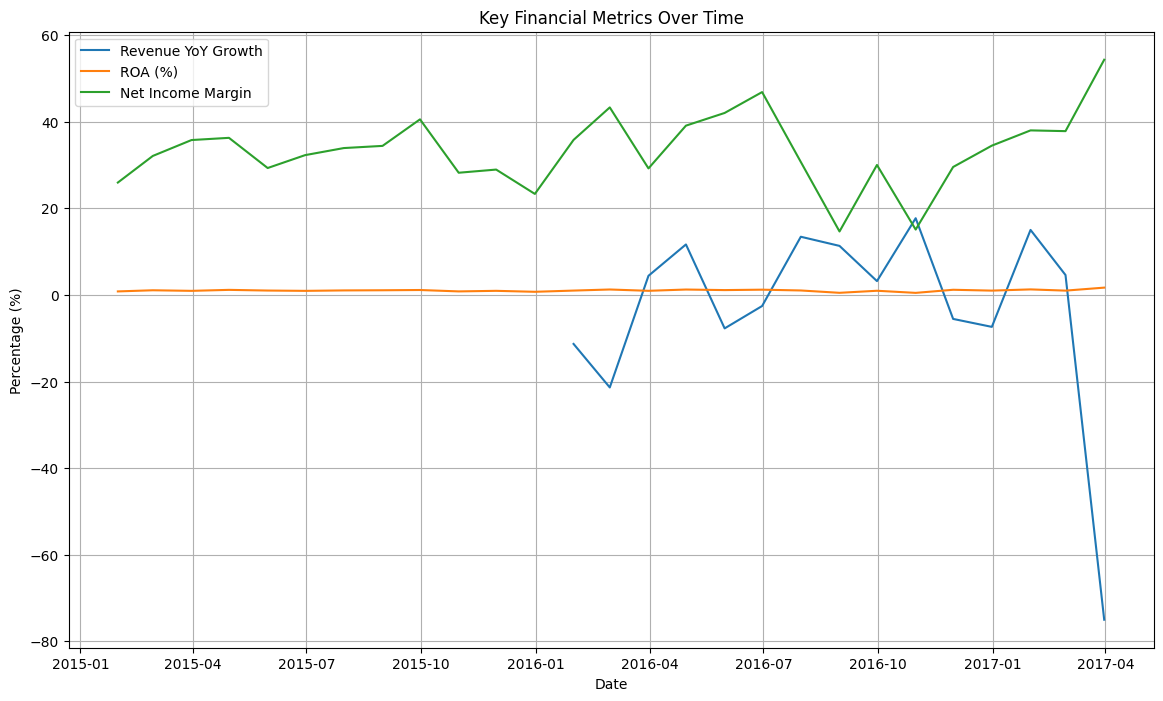

In [23]:
plt.figure(figsize=(14, 8))

plt.plot(df_Monthly.index, df_Monthly['Revenue_YoY_Growth'], label='Revenue YoY Growth')
plt.plot(df_Monthly.index, df_Monthly['ROA_calc'], label='ROA (%)')
plt.plot(df_Monthly.index, df_Monthly['Net_Income_Margin'], label='Net Income Margin')

plt.title('Key Financial Metrics Over Time')
plt.xlabel('Date')
plt.ylabel('Percentage (%)')
plt.legend()
plt.grid(True)
plt.show()


# Select only numeric columns

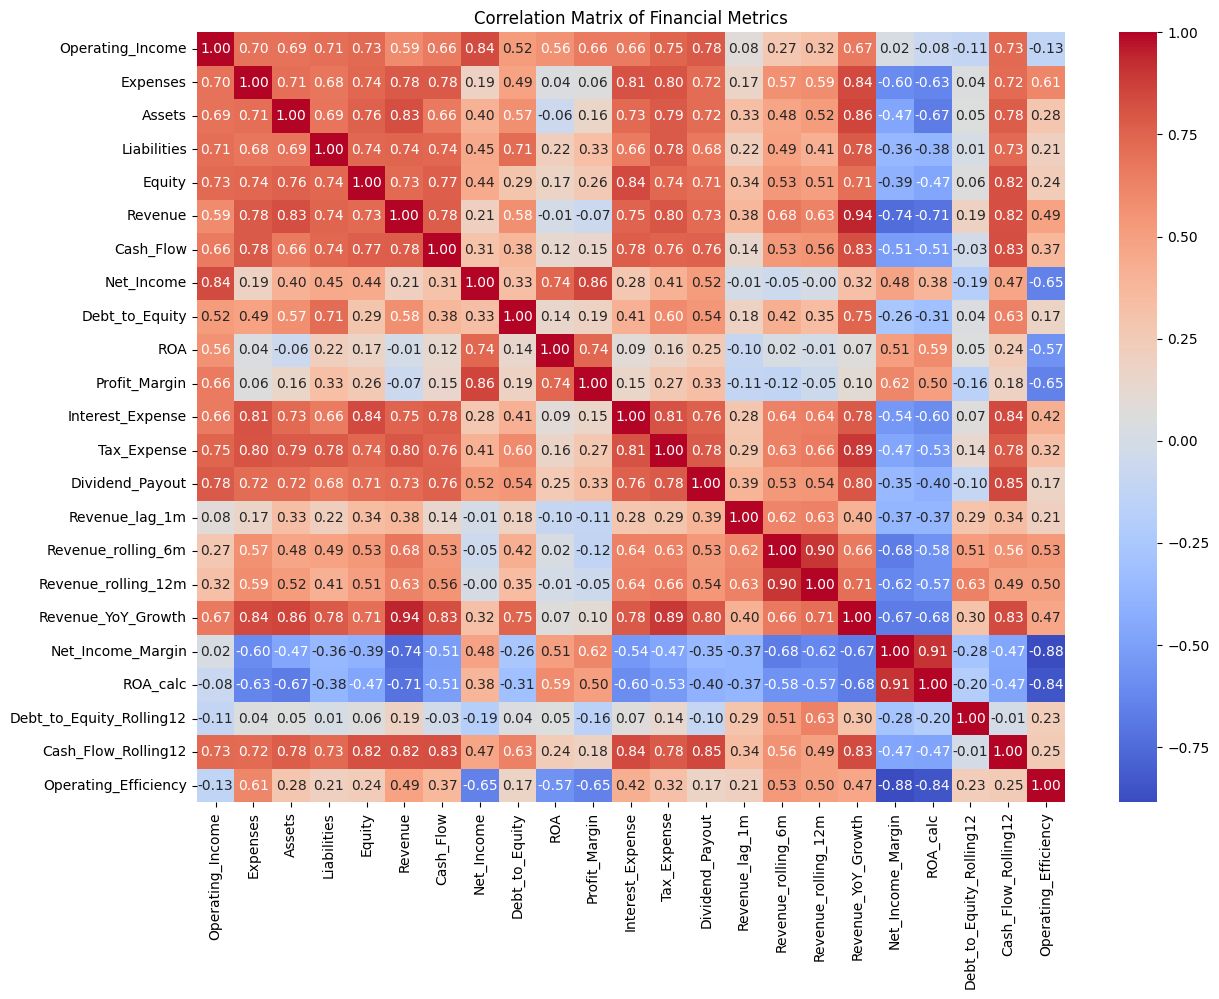

In [24]:
numerical_df = df_Monthly.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
sns.heatmap(numerical_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of Financial Metrics')
plt.show()


In [40]:
feature_cols = [ 'Revenue_lag_1m', 'Revenue_rolling_6m', 'Revenue_rolling_12m', 'Revenue_YoY_Growth', 'Net_Income_Margin', 'ROA_calc', 'Debt_to_Equity_Rolling12', 'Cash_Flow_Rolling12']
target_col= 'Revenue'

# Drop rows with NaN caused by lags/rolling

model_df = df_Monthly[feature_cols + [target_col]].dropna()

# Train and Test

In [42]:
from sklearn.model_selection import train_test_split

# 1. Train-Test Split (Time-based)
train_df= model_df[model_df.index < '2017-01-01']
test_df= model_df[model_df.index >= '2017-01-01']

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_test, y_test = test_df[feature_cols], test_df[target_col]

# Simple Forecasting Model

In [43]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

MAE: 66413186.90921665
R² Score: -0.32786880379814987


# Create Prophet dataframe

In [44]:
prophet_df = df_Monthly.reset_index()[['Date', 'Revenue']].rename(columns={'Date': 'ds', 'Revenue': 'y'})
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

# Initialize Prophet model

In [46]:
from prophet import Prophet
Prophet_model = Prophet( 
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)

# fit the model
Prophet_model.fit(prophet_df)

00:23:09 - cmdstanpy - INFO - Chain [1] start processing
00:23:09 - cmdstanpy - INFO - Chain [1] done processing


# Create future dates for next 12 months

In [47]:
future= Prophet_model.make_future_dataframe(periods=12, freq='M')
forecast = Prophet_model.predict(future)

c:\Users\Shivam\AppData\Local\Programs\Python\Python310\lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


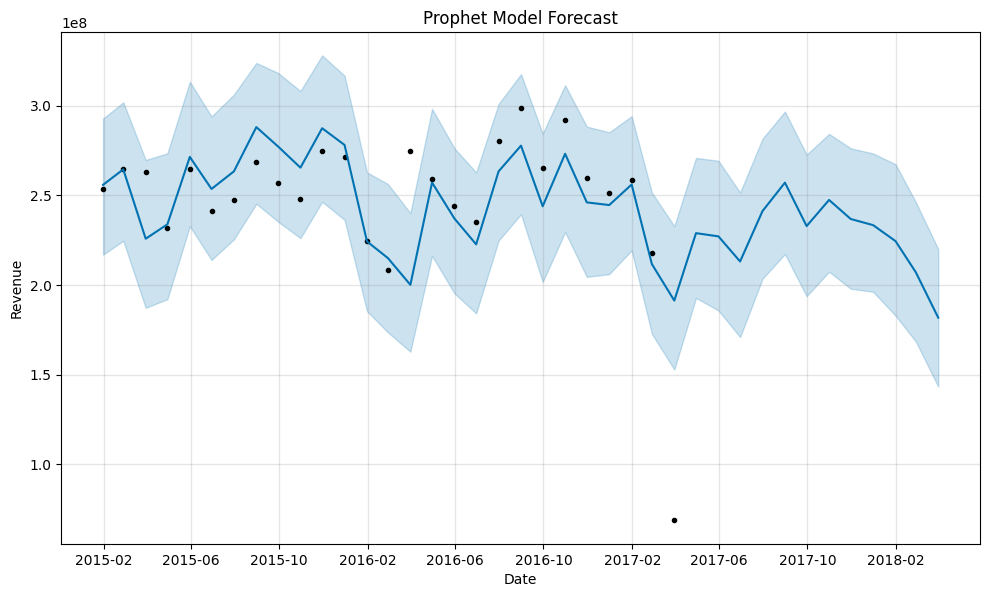

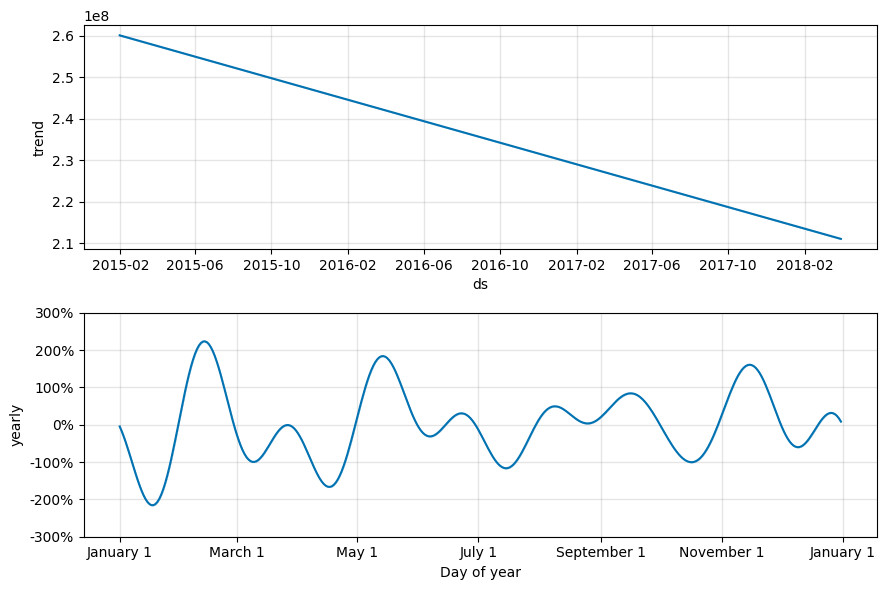

In [48]:
fig1 = Prophet_model.plot(forecast)
plt.title('Prophet Model Forecast')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.show()
fig2 = Prophet_model.plot_components(forecast)
plt.show()

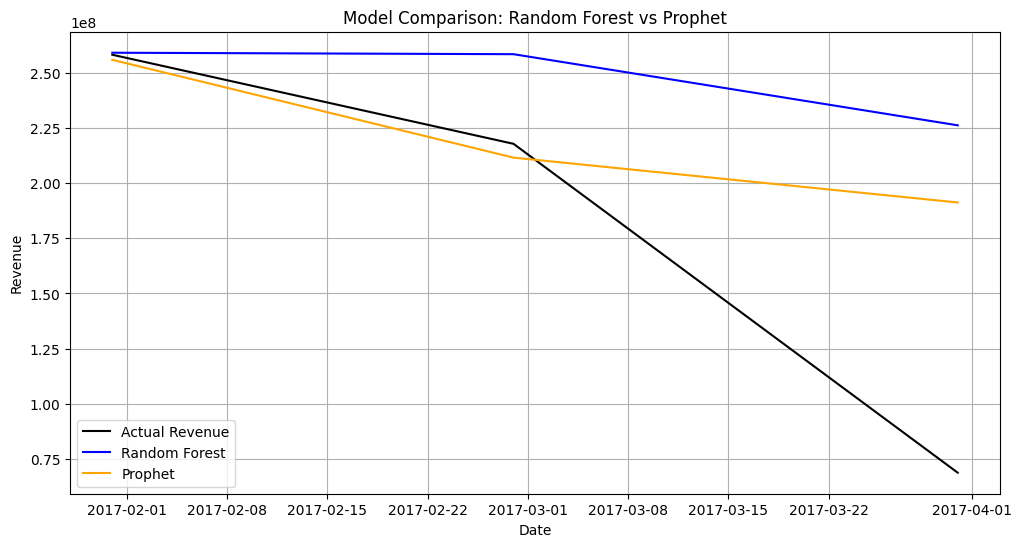

In [61]:


comparison_df = pd.DataFrame({
    'Date' : y_test.index,
    'Actual_Revenue': y_test.values,
    'RF_Predicted': y_pred
})

# Prophet predicted values for the same dates
prophet_compare = forecast.set_index('ds').loc[comparison_df['Date']]
comparison_df['Prophet_Predicted'] = prophet_compare['yhat'].values

# Plot comparison
plt.figure(figsize=(12,6))
plt.plot(comparison_df['Date'], comparison_df['Actual_Revenue'], label='Actual Revenue', color='black')
plt.plot(comparison_df['Date'], comparison_df['RF_Predicted'], label='Random Forest', color='blue')
plt.plot(comparison_df['Date'], comparison_df['Prophet_Predicted'], label='Prophet', color='orange')
plt.title('Model Comparison: Random Forest vs Prophet')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)
plt.show()

In [62]:
model_df.to_csv("model_ready_financial_data.csv", index=True)


In [63]:
df_Monthly.to_csv("cleaned_financial_data.csv", index=True)
